In [2]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pickle

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, savefig, close
import matplotlib.font_manager as fm
import itertools

import taurex
import xarray as xr
import os
import pandas as pd
import astropy

from taurex.cache import OpacityCache, CIACache
OpacityCache().set_opacity_path('./xsec/')
CIACache().set_cia_path('./cia/')

from taurex.temperature import TemperatureFile
from taurex.chemistry import TaurexChemistry
from taurex.chemistry import ConstantGas

from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar

from taurex.model import EmissionModel, TransmissionModel
from taurex.pressure import SimplePressureProfile

from taurex.contributions import AbsorptionContribution
from taurex.contributions import CIAContribution
from taurex.contributions import RayleighContribution

from taurex.binning import FluxBinner

Numba not installed, using numpy instead


In [3]:
def bindown_single(w1, d1, w2, d2, output, noise, eclipses):
    wf = (w1 + w2) / 2
    df = (w2 + d2/2) - (w1 - d1/2)

    photogrid = np.array([[wf], [df]])

    fb2 = FluxBinner(photogrid[0], photogrid[1])

    # returns wavelength, value, and error
    wl, val, err, *_ = fb2.bindown(
        output[0], output[1],
        error=noise/np.sqrt(eclipses)
    )

    return w1, w2, wl[0], val[0], err[0], df

def make_next_level_points(results):
    """
    results: list of (w1, w2, wl, val, err, df)
             length must be even
    returns: list of (w1, d1, w2, d2)
    """

    assert len(results) % 2 == 0

    new_points = []

    for i in range(0, len(results), 2):
        left_bin  = results[i]
        right_bin = results[i + 1]

        # left edge of combined bin
        w1 = left_bin[2] - left_bin[5] / 2
        # right edge of combined bin
        w2 = right_bin[2] + right_bin[5] / 2

        width = w2 - w1

        new_points.append((w1, width, w2, width))

    return new_points

def bindown_multiple(output, noise, wlgrid, fpfs, eclipses, name, *new_points):
    all_results = []

    for (w1, d1, w2, d2) in new_points:
        out_i = bindown_single(w1, d1, w2, d2, output, noise, eclipses)
        all_results.append(out_i)

    return all_results

def create_point(w1, w2):
    wb1 = wb[np.argmin(np.abs(wl - w1))]
    wb2 = wb[np.argmin(np.abs(wl - w2))]
    point = (w1, wb1, w2, wb2)
    return point

In [4]:
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
planet_masses = [4.73, 4.97, 2.33, 3.07, 1.42, 2.02, 3.48, 2.44] #Earth masses
planet_distances = [0.018, 0.007, 0.018, 0.011, 0.012, 0.011, 0.019, 0.012] #AU
planet_period = [0.96, 0.28, 1.95, 0.49, 0.55, 0.45, 1.0, 0.55] #days
planet_radius = [1.627, 1.510, 1.242, 1.277, 1.166, 1.397, 1.620, 1.496] #Earth radii
planet_transit = [1.61, 0.94, 0.71, 1.24, 0.99, 1.31, 1.5, 0.98] #hours

star_temperature = [5261,4570,3381,4850,4440,5342,4884,4914] #Kelvin
star_radius = [0.872,0.681,0.246,0.731,0.678,0.856,0.793,0.746] #Solar radii
star_metallicity = [0.03, 0.0, -0.13, 0.2, 0.12, -0.4, 0.08, -0.04] #[Fe/H]
star_logg = [4.5, 4.6, 4.9, 4.6, 4.6, 4.5, 4.5, 4.6]
star_age = [10.2, 6.3, 5.6, 5.1, 5, 11, 6.9, 0.3] #Gyr

In [5]:
#empty dictionary

planet_all = {'HD3167': {}, 'K2141': {}, 'LHS1478': {}, 'TOI431': {}, 'TOI500': {}, 'TOI561': {}, 'TOI1416': {}, 'TOI1807': {}}

# Nightside emission

In [6]:
if os.path.exists(f"ARIEL/arielrad_HD3167/tier2.csv"):
    file = f"ARIEL/arielrad_HD3167/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])

In [ ]:
wl

In [ ]:
wb

In [7]:
new_point9 = (4.305457, 0.28225, 4.5973, 0.3014)
new_point10 = (4.908865, 0.322, 5.24157, 0.344)

new_point11 = (5.59683967, 0.367, 5.97618103, 0.391)
new_point12 = (6.38, 0.418, 6.814, 0.447)

new_points = [new_point9, new_point10, new_point11, new_point12]

In [8]:
#empty pandas dataframe to store results
results_df = pd.DataFrame(columns=['Planet', 'Hydrogen Inventory [H oceans]','Redox State','Nightside Detected','Number of observations','Surface Pressure [bar]','Atmospheric Components','Transit Duration (hours)','Integration Time (hours)','Total Telescope Time (hours)','Orbital Period (hours)'])

In [7]:
results_df_3 = pd.DataFrame(columns=['Planet', 'Hydrogen Inventory [H oceans]','Redox State','Nightside Detected','Number of observations','Surface Pressure [bar]','Atmospheric Components','Transit Duration (hours)','Integration Time (hours)','Total Telescope Time (hours)','Orbital Period (hours)'])

# 1-Sigma

In [11]:
# input parameters
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
name = planet_names[1]

# was: eclipses = 35
eclipses = np.arange(6,12, 1, dtype=int)  # <- array input
eclipses = np.unique(np.sort(eclipses))  # safety: sorted + unique

binning = True
sigma = 1

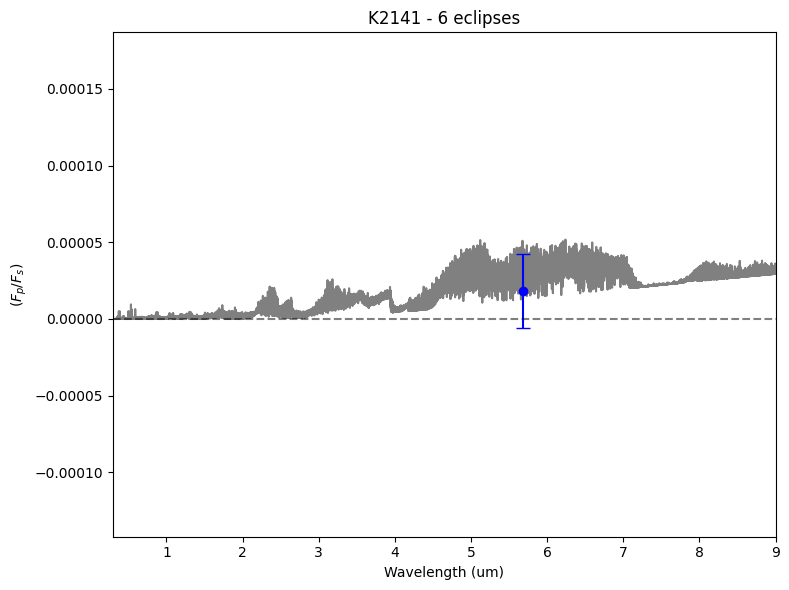

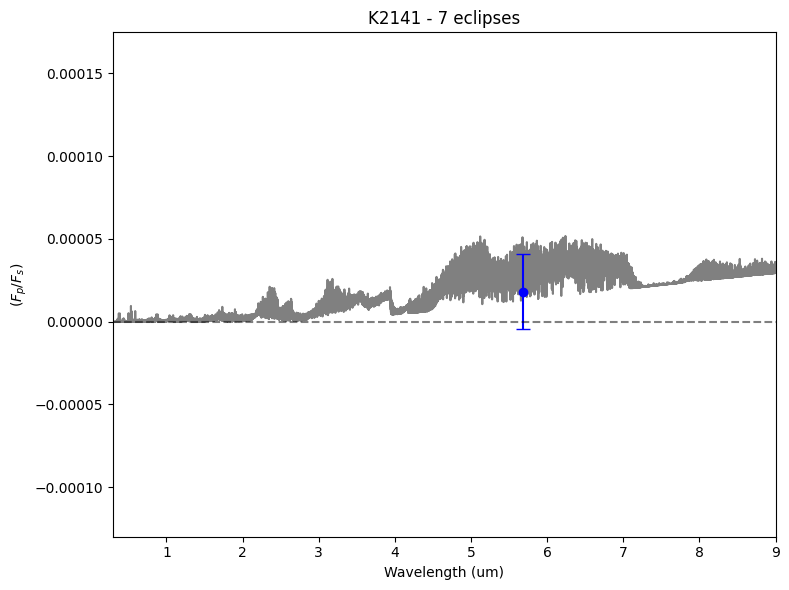

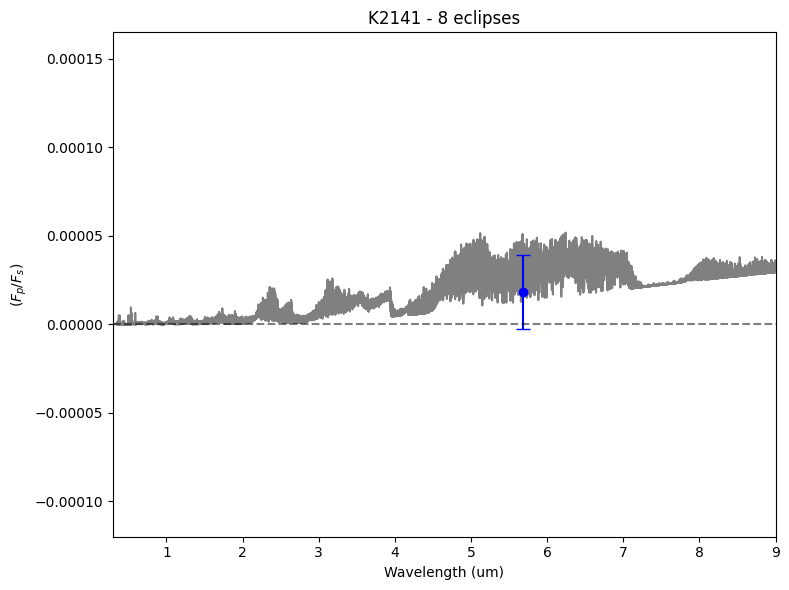

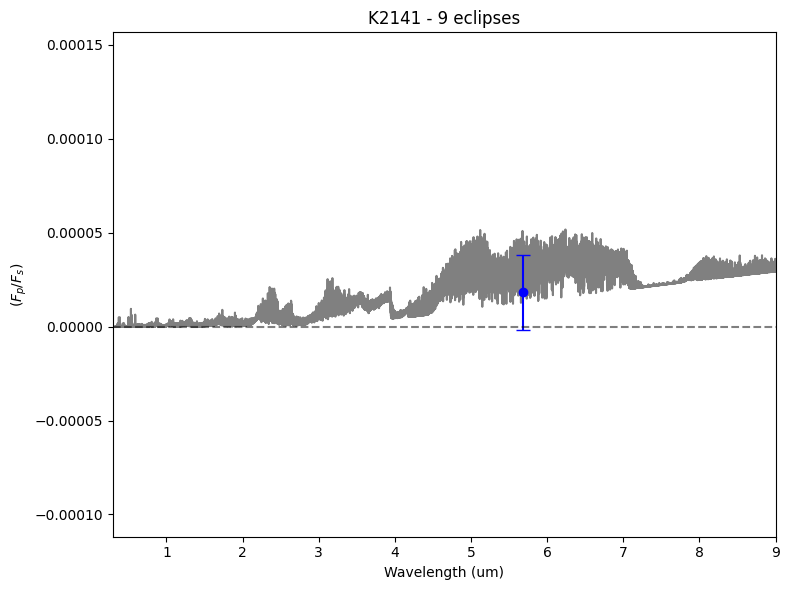

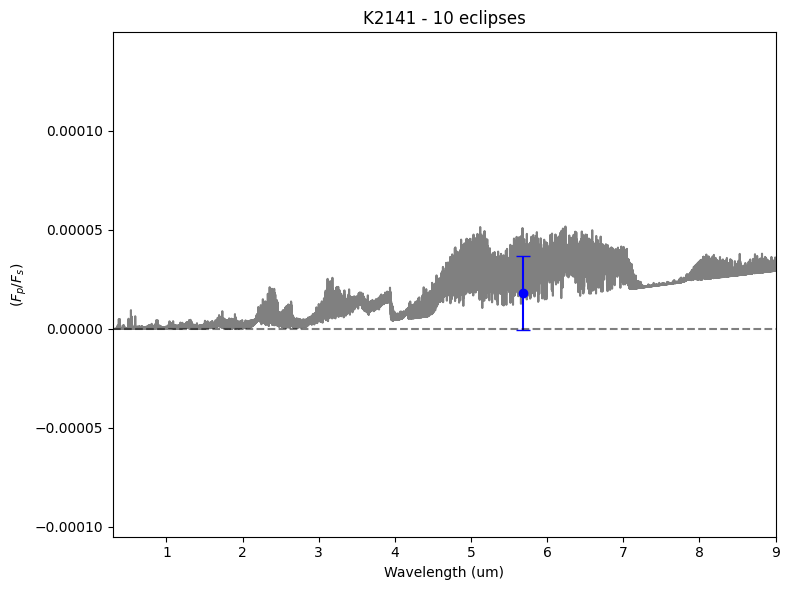

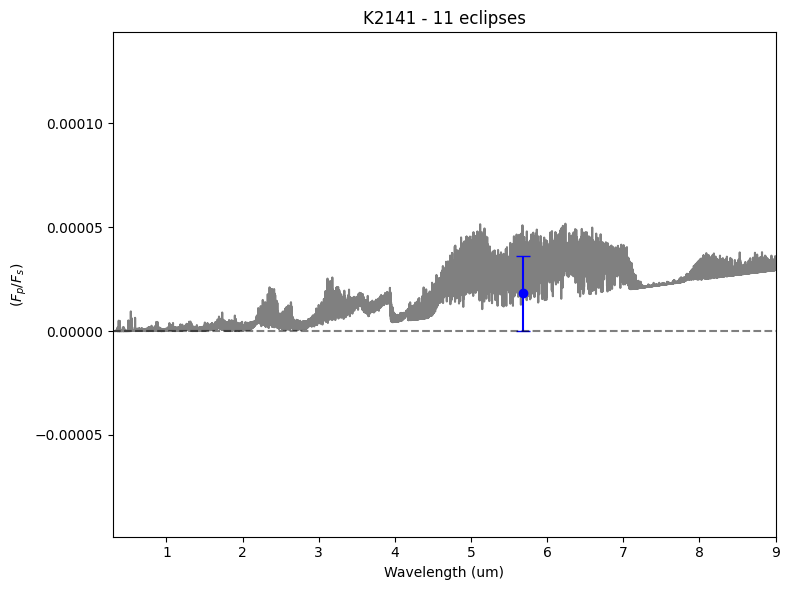

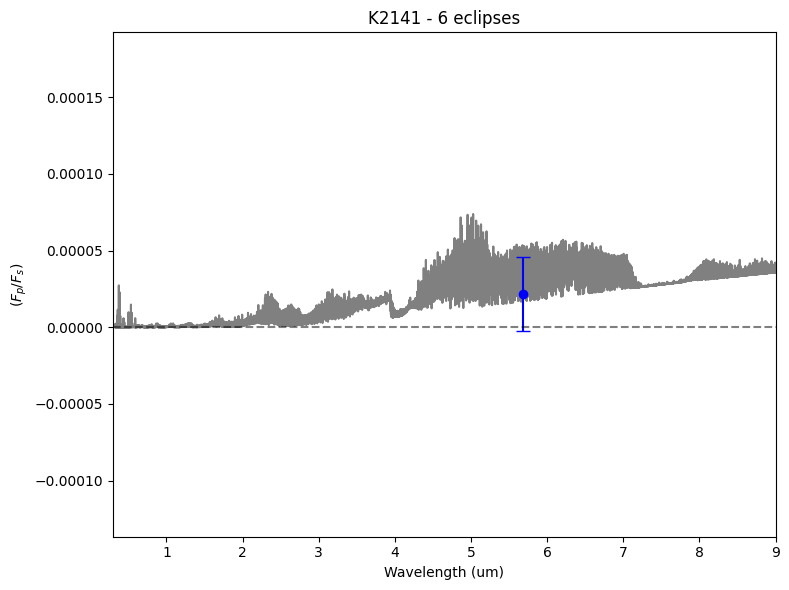

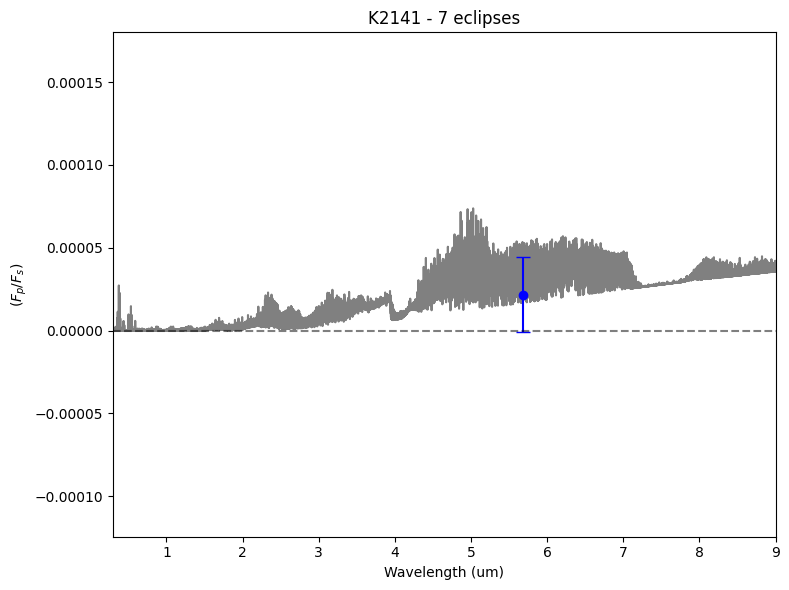

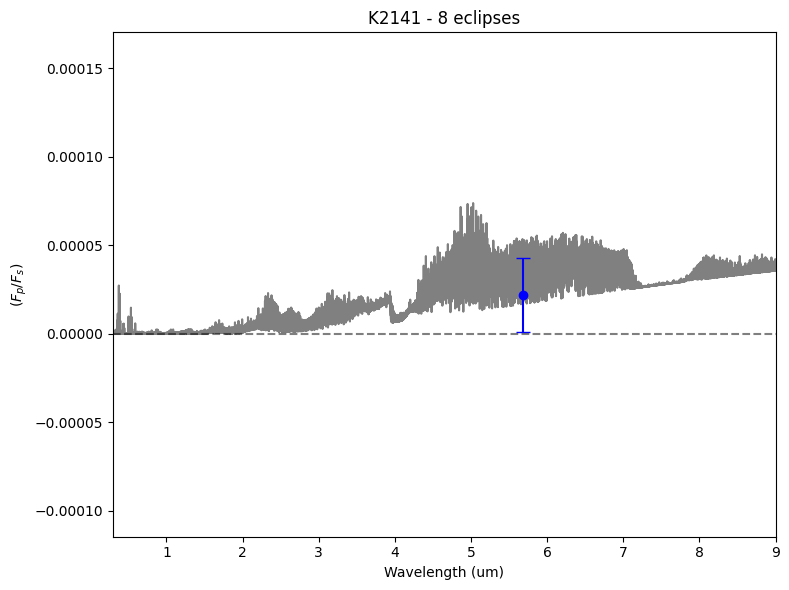

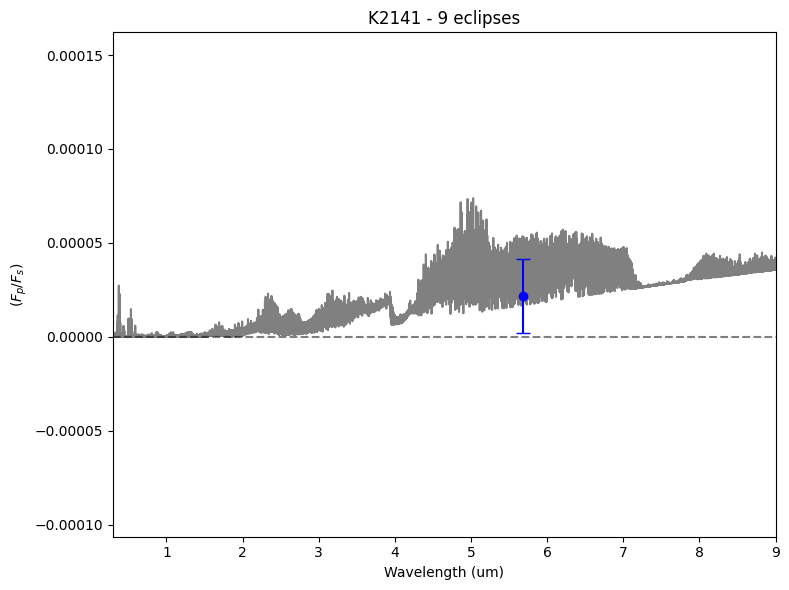

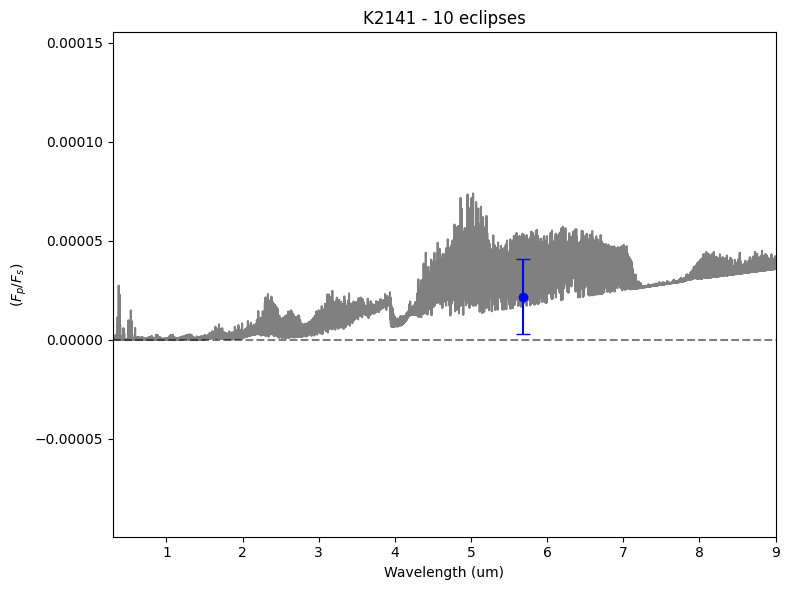

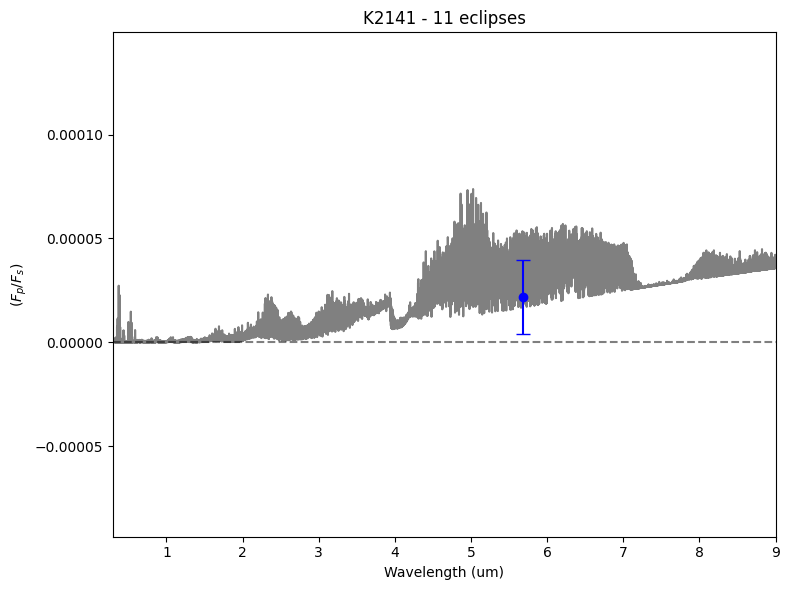

In [12]:
for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'transit_duration': planet_transit[planet_names.index(name)],
        'orbital_period': planet_period[planet_names.index(name)],
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_sma=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    #build emission model at the terminator
    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-H2','N2-H2O','O2-CO2']))
    em_terminator.add_contribution(RayleighContribution())

    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional
    # instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    
    for N in eclipses:
        detection = False
    
        plt.figure(figsize=(8,6))
        yerr = noise / np.sqrt(N) * sigma
    
        y_all = np.concatenate([output_t[1] + yerr, output_t[1] - yerr])
        ymin, ymax = y_all.min(), y_all.max()
        pad = 0.0001 * (ymax - ymin)
        plt.ylim(ymin - pad, ymax + pad)
        plt.plot(wlgrid_t, fpfs_t, color='gray')
    
        time = planet_transit[planet_names.index(name)] + 1.5 * planet_transit[planet_names.index(name)]
        #t_time = planet_period[planet_names.index(name)]*24 + (N-2)*time
        total_time = planet_period[planet_names.index(name)] * 24 * N
    
        if binning:
            results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points)
            new_points_t = make_next_level_points(results_t)
            results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_t)
            new_points_level2_t = make_next_level_points(results_level2_t)
            results_level3_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_level2_t)
    
            for out in results_level3_t:
                plt.errorbar(out[2], out[3], yerr=out[4]*sigma, capsize=5, fmt='o', color='blue')
                if out[3] - out[4]*sigma > 0:
                    detection = True
        else:
            plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='orange', alpha=0.67)
            if np.any(output_t[1] - noise/np.sqrt(N)*sigma > 0):
                detection = True
    
        plt.xlabel("Wavelength (um)")
        plt.ylabel("$(F_p/F_s)$")
        plt.xlim(0.3, 9)
        plt.title(f"{name} - {N} eclipses")
        plt.tight_layout()
        plt.hlines(y=0, xmin=0.3, xmax=9, color='black', linestyle='--', alpha=0.5)
        plt.savefig(f"PLANETS/{name}/nightside_{os.path.basename(simulation_folder)}_{N}.pdf", format='pdf')
        show()
        close()
    
        mixing_ratios = planet_all[name][sim_name]['mixing_ratios']
        sorted_gases = sorted(mixing_ratios.items(), key=lambda x: x[1], reverse=True)
        dom_gases = sorted_gases[:2]
        dom_gases_str = f"{dom_gases[0][0]}, {dom_gases[1][0]}"
    
        results_df.loc[len(results_df)] = [
            name,
            simulation_folder.split('/')[2].split('_')[0],
            simulation_folder.split('_')[1],
            detection,
            N,
            pmax/1e5, #convert Pa to bar
            dom_gases_str,
            planet_transit[planet_names.index(name)],
            time,
            total_time,
            planet_period[planet_names.index(name)]*24
        ]

In [11]:
results_df

,Planet,Hydrogen Inventory [H oceans],Redox State,Nightside Detected,Number of observations,Surface Pressure [bar],Atmospheric Components,Transit Duration (hours),Integration Time (hours),Total Telescope Time (hours),Orbital Period (hours)
0,HD3167,H20,IW4,False,12,301.889080,"CO2, N2",1.61,63.290,138.24,23.04
1,HD3167,H20,IW4,True,13,301.889080,"CO2, N2",1.61,67.315,149.76,23.04
2,HD3167,H20,IW4,True,14,301.889080,"CO2, N2",1.61,71.340,161.28,23.04
3,HD3167,H20,IW4,True,15,301.889080,"CO2, N2",1.61,75.365,172.80,23.04
4,HD3167,H10,IW4,False,12,10.902882,"SO2, H2O",1.61,63.290,138.24,23.04
5,HD3167,H10,IW4,False,13,10.902882,"SO2, H2O",1.61,67.315,149.76,23.04
6,HD3167,H10,IW4,False,14,10.902882,"SO2, H2O",1.61,71.340,161.28,23.04
7,HD3167,H10,IW4,True,15,10.902882,"SO2, H2O",1.61,75.365,172.80,23.04


# 3-Sigma

In [ ]:
# input parameters
planet_names = ["HD3167","K2141","LHS1478","TOI431","TOI500","TOI561","TOI1416","TOI1807"]
name = planet_names[6]

# was: eclipses = 35
eclipses = np.arange(300,500, 10, dtype=int)  # <- array input
eclipses = np.unique(np.sort(eclipses))  # safety: sorted + unique

binning = True
sigma = 3

In [ ]:
for folder in os.listdir(f"PLANETS/{name}/"):
    simulation_folder = os.path.join(f"PLANETS/{name}/", folder)
    #check if it is a directory
    if not os.path.isdir(simulation_folder):
        continue

    #set-up directories and paths
    outputdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}"
    planetdir = f"PLANETS/{name}/{os.path.basename(simulation_folder)}_TP.csv"
    
    temp_profile_terminator = TemperatureFile(planetdir, skiprows=1,
                               temp_col=1, press_col=0,
                               temp_units='K', press_units='Pa',
                               delimiter = ',')
    
    #read-in the atmospheric composition
    atm_file = None
    for file in os.listdir(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/"):
        if file.endswith("atm.nc"):
            atm_file = os.path.join(f"PLANETS/{name}/{os.path.basename(simulation_folder)}/", file)
            #save filename without extension
            filename = os.path.splitext(atm_file)[0]
            break

    ds = xr.open_dataset(atm_file)

    #extract gas names
    gases = np.array(ds['gases'])
    gases = [m.decode().strip() for m in ds["gases"].values]
    vmr = np.array(ds['x_gas'])

    pressure = np.array(ds['p']) #pressure in Pa
    pmax = pressure.max()
    pmin = pressure.min()

    radius = float(ds['planet_radius']) #planet radius in m
    #convert to Jupiter radii
    radius = radius / astropy.constants.R_jup.value

    #get mixing ratio of each molecule
    H2O_x = float(vmr[:, gases.index('H2O')][0])
    CO2_x = float(vmr[:, gases.index('CO2')][0])
    CH4_x = float(vmr[:, gases.index('CH4')][0])
    CO_x = float(vmr[:, gases.index('CO')][0])
    NH3_x = float(vmr[:, gases.index('NH3')][0])
    N2_x = float(vmr[:, gases.index('N2')][0])
    SO2_x = float(vmr[:, gases.index('SO2')][0])
    S2_x = float(vmr[:, gases.index('S2')][0])
    O2_x = float(vmr[:, gases.index('O2')][0])
    H2_x = float(vmr[:, gases.index('H2')][0])
    H2S_x = float(vmr[:, gases.index('H2S')][0])

    #save in dictionary the planet name, simulation folder, temperature profiles and mixing ratios
    sim_name = os.path.basename(simulation_folder)
    planet_all[name][sim_name] = {
        'simulation_folder': simulation_folder,
        'temp_profile_terminator': temp_profile_terminator,
        'surface_pressure': pmax,
        'transit_duration': planet_transit[planet_names.index(name)],
        'orbital_period': planet_period[planet_names.index(name)],
        'mixing_ratios': {
            'H2O': H2O_x,
            'CO2': CO2_x,
            'CH4': CH4_x,
            'CO': CO_x,
            'NH3': NH3_x,
            'N2': N2_x,
            'SO2': SO2_x,
            'S2': S2_x,
            'O2': O2_x,
            'H2': H2_x,
            'H2S': H2S_x
        }
    }

    #define chemistry
    chemistry = TaurexChemistry(fill_gases=["N2"])

    # check that the sum of all vmr is less or equal to 1
    total_vmr = H2O_x + CO2_x + CH4_x + CO_x + NH3_x + N2_x + SO2_x + S2_x + O2_x + H2_x + H2S_x
    if total_vmr > 1:
        #renormalize the vmr values
        H2O_x = H2O_x / total_vmr
        CO2_x = CO2_x / total_vmr
        CH4_x = CH4_x / total_vmr
        CO_x = CO_x / total_vmr
        NH3_x = NH3_x / total_vmr
        N2_x = N2_x / total_vmr
        SO2_x = SO2_x / total_vmr
        S2_x = S2_x / total_vmr
        O2_x = O2_x / total_vmr
        H2_x = H2_x / total_vmr
        H2S_x = H2S_x / total_vmr

    chemistry.addGas(ConstantGas(molecule_name="NH3", mix_ratio=NH3_x)).addGas(ConstantGas(molecule_name="CO2", mix_ratio=CO2_x)).addGas(ConstantGas(molecule_name="H2O", mix_ratio=H2O_x)).addGas(ConstantGas(molecule_name="CH4", mix_ratio=CH4_x)).addGas(ConstantGas(molecule_name="CO", mix_ratio=CO_x)).addGas(ConstantGas(molecule_name="SO2", mix_ratio=SO2_x)).addGas(ConstantGas(molecule_name="S2", mix_ratio=S2_x)).addGas(ConstantGas(molecule_name="O2", mix_ratio=O2_x)).addGas(ConstantGas(molecule_name="H2", mix_ratio=H2_x)).addGas(ConstantGas(molecule_name="H2S", mix_ratio=H2S_x))

    mass = planet_masses[planet_names.index(name)] #Earth masses
    #convert to jupiter masses
    mass = mass / 317.8
    #semi-major axis
    a = planet_distances[planet_names.index(name)] #AU
    #set-up planet in Jupiter masses and radii
    planet = Planet(planet_mass=mass, planet_radius= radius, planet_distance=a)

    star = PhoenixStar(temperature=star_temperature[int(planet_names.index(name))], radius=star_radius[int(planet_names.index(name))], metallicity=star_metallicity[int(planet_names.index(name))], phoenix_path='Phoenix/')

    #build emission model at the terminator
    em_terminator = EmissionModel( 
    planet=planet,
    temperature_profile=temp_profile_terminator,
    chemistry=chemistry,
    pressure_profile=SimplePressureProfile(atm_min_pressure=pmin, atm_max_pressure=pmax, nlayers=100),
    star=star,
    )

    em_terminator.add_contribution(AbsorptionContribution())
    em_terminator.add_contribution(CIAContribution(cia_pairs=['CO2-CH4','CO2-CO2','CO2-H2','CO2-H2O','H2-H2','N2-CH4','N2-H2','N2-H2O','N2-N2','O2-CO2','O2-N2','O2-O2']))
    em_terminator.add_contribution(RayleighContribution())

    em_terminator.build()

    #wavenumber grid, flux ratio, and transit depth
    wngrid_t, fpfs_t, tau_t, _ = em_terminator.model()

    wlgrid_t = 10000/wngrid_t[::-1]
    fpfs_t = fpfs_t[::-1]

    #read-in Ariel noise model
    #check if file exists
    
    if os.path.exists(f"ARIEL/arielrad_{name}/tier2.csv"):
        file = f"ARIEL/arielrad_{name}/tier2.csv"

    ariel = pd.read_csv(file,skiprows=6)
    wl = np.array(ariel['Wavelength [um]'])
    wb = np.array(ariel['Bandwidth [um]'])
    noise = np.array(ariel['Noise on Transit Floor [ppm]']) * 1e-6 #converts ppm to fractional
    # instantiate flux binner with Ariel's wavelength binning
    fb = FluxBinner(wl, wb)
    output_t = fb.bindown(wlgrid_t, fpfs_t)
    
    for N in eclipses:
        detection = False
    
        plt.figure(figsize=(8,6))
        yerr = noise / np.sqrt(N) * sigma
    
        y_all = np.concatenate([output_t[1] + yerr, output_t[1] - yerr])
        ymin, ymax = y_all.min(), y_all.max()
        pad = 0.0001 * (ymax - ymin)
        plt.ylim(ymin - pad, ymax + pad)
        plt.plot(wlgrid_t, fpfs_t, color='gray')
    
        time = planet_transit[planet_names.index(name)] + 1.5 * planet_transit[planet_names.index(name)]
        t_time = planet_period[planet_names.index(name)]*24 + (N-2)*time
        total_time = planet_period[planet_names.index(name)]*24 + (N-2)/2 * (planet_period[planet_names.index(name)]*24)
    
        if binning:
            results_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points)
            new_points_t = make_next_level_points(results_t)
            results_level2_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_t)
            new_points_level2_t = make_next_level_points(results_level2_t)
            results_level3_t = bindown_multiple(output_t, noise, wlgrid_t, fpfs_t, N, name, *new_points_level2_t)
    
            for out in results_level3_t:
                plt.errorbar(out[2], out[3], yerr=out[4]*sigma, capsize=5, fmt='o', color='blue')
                if out[3] - out[4]*sigma > 0:
                    detection = True
        else:
            plt.errorbar(output_t[0], output_t[1], yerr=noise/np.sqrt(N)*sigma, capsize=5, fmt='o', color='orange', alpha=0.67)
            if np.any(output_t[1] - noise/np.sqrt(N)*sigma > 0):
                detection = True
    
        plt.xlabel("Wavelength (um)")
        plt.ylabel("$(F_p/F_s)$")
        plt.xlim(0.3, 9)
        plt.title(f"{name} - {N} eclipses")
        plt.tight_layout()
        plt.hlines(y=0, xmin=0.3, xmax=9, color='black', linestyle='--', alpha=0.5)
        plt.savefig(f"PLANETS/{name}/nightside_{os.path.basename(simulation_folder)}_{N}.pdf", format='pdf')
        show()
        close()
    
        mixing_ratios = planet_all[name][sim_name]['mixing_ratios']
        sorted_gases = sorted(mixing_ratios.items(), key=lambda x: x[1], reverse=True)
        dom_gases = sorted_gases[:2]
        dom_gases_str = f"{dom_gases[0][0]}, {dom_gases[1][0]}"
    
        results_df_3.loc[len(results_df_3)] = [
            name,
            simulation_folder.split('/')[2].split('_')[0],
            simulation_folder.split('_')[1],
            detection,
            N,
            pmax/1e5, #convert Pa to bar
            dom_gases_str,
            planet_transit[planet_names.index(name)],
            t_time,
            total_time,
            planet_period[planet_names.index(name)]*24
        ]

In [ ]:
results_df_3[results_df_3['Planet'] == "TOI1416"]

In [7]:
#open both successes dataframes

success_df = pd.read_csv("nightside_success.csv", index_col=0)
success_df_3sigma = pd.read_csv("nightside_success_3.csv", index_col=0)

In [13]:
#check all entries of results_df and if nightside is detected, add to success_df the row with lower number of observations
for index, row in results_df.iterrows():
    if row['Nightside Detected']:
        success_df.loc[len(success_df)] = row

In [ ]:
for index, row in results_df_3.iterrows():
    if row['Nightside Detected']:
        success_df_3sigma.loc[len(success_df_3sigma)] = row

In [14]:
#keep only one entry per planet, combined with Hydrogen and Redox State case, with the lowest number of observations in success_df
success_df = success_df.groupby(['Planet', 'Hydrogen Inventory [H oceans]', 'Redox State', 'Surface Pressure [bar]']).apply(lambda x: x.loc[x['Number of observations'].idxmin()]).reset_index(drop=True)

In [9]:
# in success_df replace values in Integration Time (hours) with Number of Observations * Orbital Period (hours)
success_df['Integration Time (hours)'] = success_df['Number of observations'] * success_df['Orbital Period (hours)']
#drop Total Telescope Time (hours) column
success_df = success_df.drop(columns=['Total Telescope Time (hours)'])

In [ ]:
success_df_3sigma = success_df_3sigma.groupby(['Planet', 'Hydrogen Inventory [H oceans]', 'Redox State', 'Surface Pressure [bar]']).apply(lambda x: x.loc[x['Number of observations'].idxmin()]).reset_index(drop=True)

In [10]:
success_df

,Planet,Hydrogen Inventory [H oceans],Redox State,Nightside Detected,Number of observations,Surface Pressure [bar],Atmospheric Components,Transit Duration (hours),Integration Time (hours),Orbital Period (hours)
0,HD3167,H10,IW4,True,15,10.902882,"SO2, H2O",1.61,345.60,23.04
1,HD3167,H20,IW4,True,13,301.889080,"CO2, N2",1.61,299.52,23.04
2,K2141,H10,IW4,True,8,37.155537,"SO2, H2O",0.94,53.76,6.72
3,K2141,H10,IW4,True,11,474.718534,"SO2, S2",0.94,73.92,6.72
4,LHS1478,H05,IW0,True,10000,317.212366,"H2O, S2",0.71,468000.00,46.80
5,LHS1478,H05,IW4,True,10000,2693.216197,"CO2, H2O",0.71,468000.00,46.80
6,TOI1416,H10,IW0,True,30,4.994660,"H2, H2O",1.50,720.00,24.00
7,TOI1416,H10,IW4,True,49,55.970885,"CO2, SO2",1.50,1176.00,24.00
8,TOI1416,H20,IW0,True,35,437.019741,"CO, N2",1.50,840.00,24.00
9,TOI1807,H10,IW0,True,21,153.474293,"CO, N2",0.98,277.20,13.20


In [ ]:
#drop specific rows from success_df_3sigma based on index
#success_df_3sigma = success_df_3sigma.drop(index=[2,3])

In [11]:
success_df.to_csv(f"nightside_success.csv", index=True)

In [6]:
success_df_3sigma

,Planet,Hydrogen Inventory [H oceans],Redox State,Nightside Detected,Number of observations,Surface Pressure [bar],Atmospheric Components,Transit Duration (hours),Integration Time (hours),Total Telescope Time (hours),Orbital Period (hours)
0,HD3167,H10,IW4,True,127,10.902882,"SO2, H2O",1.61,526.165,1463.04,23.04
1,HD3167,H20,IW4,True,111,301.889080,"CO2, N2",1.61,461.765,1278.72,23.04
2,K2141,H10,IW4,True,68,37.155537,"SO2, H2O",0.94,161.820,228.48,6.72
3,K2141,H10,IW4,True,97,474.718534,"SO2, S2",0.94,229.970,325.92,6.72
4,LHS1478,H05,IW0,True,74000,317.212366,"H2O, S2",0.71,131393.250,1731600.00,46.80
5,LHS1478,H05,IW4,True,67000,2693.216197,"CO2, H2O",0.71,118968.250,1567800.00,46.80
6,TOI1416,H10,IW0,True,250,4.994660,"H2, H2O",1.50,954.000,3000.00,24.00
7,TOI1416,H10,IW4,True,450,55.970885,"CO2, SO2",1.50,1704.000,5400.00,24.00
8,TOI1416,H20,IW0,True,320,437.019741,"CO, N2",1.50,1216.500,3840.00,24.00
9,TOI1807,H10,IW0,True,185,153.474293,"CO, N2",0.98,461.550,1221.00,13.20


In [ ]:
success_df_3sigma.to_csv(f"nightside_success_3.csv", index=True)